# Task 3 — Forecast Future Market Trends (TSLA)

**Portfolio Optimization Challenge (Week 9)** · Target: **TSLA Adjusted Close**

> **Objective.** Use the best model from Task 2 to forecast Tesla's price **12 months into the future**,
> visualize it with **confidence intervals**, and translate the result into actionable trend analysis,
> opportunities, risks, and an honest assessment of how reliable the forecast is at different horizons.

**Best model (from Task 2):** `auto_arima` selected **ARIMA(0,1,0)** — a random walk — which beat the
LSTM on the one-step test task (MAPE 2.53% vs 5.99%). We use it here as the primary forecaster because
it (a) won on accuracy and (b) ships **native, calibrated confidence intervals** — essential for this
task. For completeness we also generate an **iterative multi-step LSTM** forecast to contrast the two
approaches.

**Three layers, clearly distinguished throughout:** historical actuals · test-period predictions ·
future forecast (with CI).


## 1 · Setup & data

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.titleweight"] = "bold"

SEED = 42
np.random.seed(SEED)

C_HIST, C_TEST, C_TESTPRED = "#4C78A8", "#54A24B", "#F58518"
C_FCAST, C_CI, C_DRIFT, C_LSTM = "#E45756", "#E45756", "#72B7B2", "#B279A2"

DATA = Path("../data/processed/prices.csv")
if DATA.exists():
    prices = pd.read_csv(DATA, parse_dates=["Date"])
else:
    import yfinance as yf
    d = yf.download("TSLA", start="2015-01-01", end="2026-07-01",
                    auto_adjust=False, progress=False)
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)
    prices = d.reset_index().assign(Ticker="TSLA")

tsla = (prices[prices["Ticker"] == "TSLA"]
        .set_index("Date")["Adj Close"].sort_index().astype(float).asfreq("B").ffill())

SPLIT = "2025-01-01"
train, test = tsla[tsla.index < SPLIT], tsla[tsla.index >= SPLIT]
ORDER = (0, 1, 0)   # best model from Task 2
last_price, last_date = tsla.iloc[-1], tsla.index[-1]
print(f"TSLA: {len(tsla)} obs, {tsla.index.min().date()} → {last_date.date()} | last price ${last_price:.2f}")
print(f"Best model from Task 2: ARIMA{ORDER}")

TSLA: 2998 obs, 2015-01-02 → 2026-06-30 | last price $420.60
Best model from Task 2: ARIMA(0, 1, 0)


## 2 · Anchor: reproduce the test-period predictions

Before forecasting the unknown future, we reproduce the model's behaviour on the **known** test window
(2025 → 2026-06) via walk-forward one-step-ahead prediction. This is the "test predictions" layer that
lets a reader judge the model against reality before trusting the future path.

In [2]:
from statsmodels.tsa.arima.model import ARIMA

fit_train = ARIMA(train, order=ORDER).fit()
res, test_pred = fit_train, []
for actual in test.values:
    test_pred.append(res.forecast(steps=1).iloc[0])
    res = res.append([actual], refit=False)
test_pred = pd.Series(test_pred, index=test.index)

mape = np.mean(np.abs((test.values - test_pred.values) / test.values)) * 100
print(f"Test-period one-step MAPE: {mape:.2f}%  (matches Task 2)")

Test-period one-step MAPE: 2.53%  (matches Task 2)


## 3 · Generate the 12-month future forecast

For a genuine forward forecast we **refit the model on the full history** (all data through the last
observation) — no data is wasted. We forecast **252 business days (~12 months)** ahead and extract the
point forecast with **80% and 95% confidence intervals** from ARIMA's native `get_forecast()`.

In [3]:
HORIZON = 252   # ~12 months of business days
full_fit = ARIMA(tsla, order=ORDER).fit()
fc = full_fit.get_forecast(steps=HORIZON)

future = fc.predicted_mean
ci95 = fc.conf_int(alpha=0.05); ci95.columns = ["lo95", "hi95"]
ci80 = fc.conf_int(alpha=0.20); ci80.columns = ["lo80", "hi80"]
future_idx = future.index

print(f"Forecast horizon: {future_idx[0].date()} → {future_idx[-1].date()} ({HORIZON} business days)")
print(f"Point forecast (flat, random walk): ${future.iloc[-1]:.2f}")
print(f"95% CI at +12m: ${ci95['lo95'].iloc[-1]:.2f}  →  ${ci95['hi95'].iloc[-1]:.2f}")

Forecast horizon: 2026-07-01 → 2027-06-17 (252 business days)
Point forecast (flat, random walk): $420.60
95% CI at +12m: $197.26  →  $643.94


**Sensitivity — a random-walk-with-drift scenario.** ARIMA(0,1,0) has *no* drift term, so its point
forecast is flat at the last price. That is the statistically honest baseline. To bracket the outlook we
also fit a **drift variant** (`trend='t'`) that extrapolates TSLA's historical upward tendency, and we
check whether that drift is even statistically significant.

In [4]:
drift_fit = ARIMA(tsla, order=ORDER, trend="t").fit()
drift_fc = drift_fit.get_forecast(steps=HORIZON).predicted_mean
# significance of the drift coefficient
p_drift = drift_fit.pvalues.get("x1", np.nan)
print(f"Drift-scenario endpoint (+12m): ${drift_fc.iloc[-1]:.2f}")
print(f"Drift coefficient p-value: {p_drift:.3f} "
      f"({'significant' if p_drift < 0.05 else 'NOT significant → flat baseline is the honest call'})")

Drift-scenario endpoint (+12m): $454.74
Drift coefficient p-value: 0.302 (NOT significant → flat baseline is the honest call)


## 4 · Forecast Visualization with Confidence Intervals

Historical actuals (blue/green), test predictions (orange), and the future forecast (red) with 80% and
95% CI bands are drawn on one timeline, with markers at the train/test split and the forecast start.

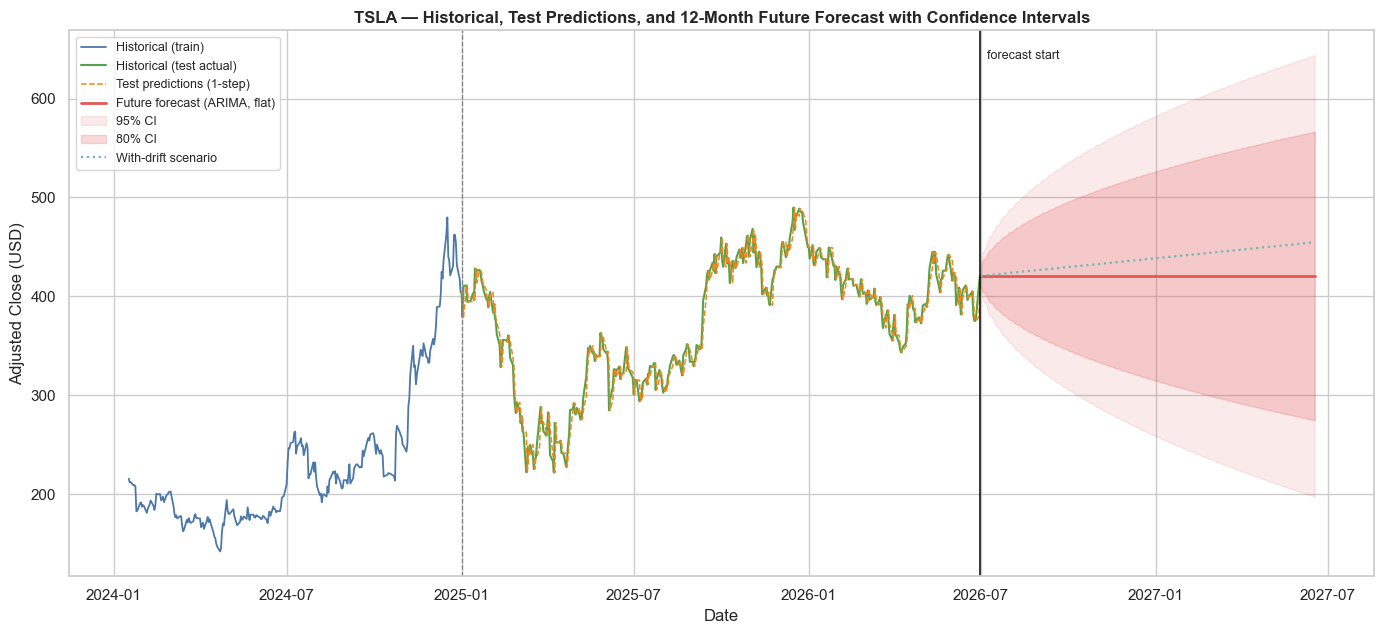

In [5]:
fig, ax = plt.subplots(figsize=(14, 6.5))

# --- historical (show last ~1.5y of train + all test for readability) ---
hist_tail = train.iloc[-250:]
ax.plot(hist_tail.index, hist_tail, color=C_HIST, lw=1.3, label="Historical (train)")
ax.plot(test.index, test, color=C_TEST, lw=1.5, label="Historical (test actual)")
ax.plot(test_pred.index, test_pred, color=C_TESTPRED, lw=1.1, ls="--", label="Test predictions (1-step)")

# --- future forecast + CI ---
ax.plot(future_idx, future, color=C_FCAST, lw=2, label="Future forecast (ARIMA, flat)")
ax.fill_between(future_idx, ci95["lo95"], ci95["hi95"], color=C_CI, alpha=0.12, label="95% CI")
ax.fill_between(future_idx, ci80["lo80"], ci80["hi80"], color=C_CI, alpha=0.22, label="80% CI")
ax.plot(future_idx, drift_fc, color=C_DRIFT, lw=1.6, ls=":", label="With-drift scenario")

# --- markers ---
ax.axvline(pd.Timestamp(SPLIT), color="grey", ls="--", lw=0.9)
ax.axvline(last_date, color="black", ls="-", lw=1.1)
ax.text(last_date, ax.get_ylim()[1]*0.97, "  forecast start", fontsize=9, va="top")
ax.set_title("TSLA — Historical, Test Predictions, and 12-Month Future Forecast with Confidence Intervals")
ax.set_ylabel("Adjusted Close (USD)"); ax.set_xlabel("Date"); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

## 5 · How the confidence interval widens over the horizon

For a random walk the forecast standard error grows with **√horizon**, so the CI fans out. We quantify
the 95% CI width (absolute \$ and as % of the point forecast) at 1, 3, 6, 9, and 12 months.

In [6]:
marks = {"1 month": 21, "3 months": 63, "6 months": 126, "9 months": 189, "12 months": 252}
rows = []
for label, h in marks.items():
    i = h - 1
    width = ci95["hi95"].iloc[i] - ci95["lo95"].iloc[i]
    rows.append({
        "Horizon": label,
        "Forecast $": round(future.iloc[i], 2),
        "95% low $": round(ci95["lo95"].iloc[i], 2),
        "95% high $": round(ci95["hi95"].iloc[i], 2),
        "CI width $": round(width, 2),
        "CI width % of price": round(width / future.iloc[i] * 100, 1),
    })
ci_table = pd.DataFrame(rows).set_index("Horizon")
ci_table

,Forecast $,95% low $,95% high $,CI width $,CI width % of price
Horizon,,,,,
1 month,420.6,356.13,485.07,128.95,30.7
3 months,420.6,308.93,532.27,223.34,53.1
6 months,420.6,262.67,578.53,315.85,75.1
9 months,420.6,227.18,614.02,386.84,92.0
12 months,420.6,197.26,643.94,446.68,106.2


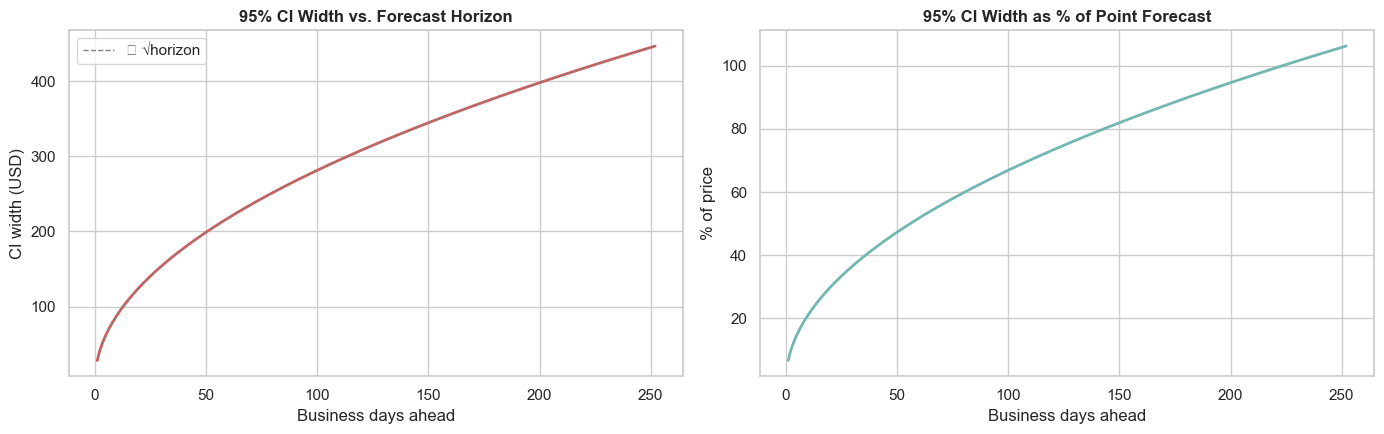

In [7]:
h_axis = np.arange(1, HORIZON + 1)
width_series = (ci95["hi95"].values - ci95["lo95"].values)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(h_axis, width_series, color=C_FCAST, lw=2)
axes[0].set_title("95% CI Width vs. Forecast Horizon"); axes[0].set_xlabel("Business days ahead")
axes[0].set_ylabel("CI width (USD)")
axes[0].plot(h_axis, width_series[0]*np.sqrt(h_axis), color="grey", ls="--", lw=1, label="∝ √horizon")
axes[0].legend()

axes[1].plot(h_axis, width_series / future.values * 100, color=C_DRIFT, lw=2)
axes[1].set_title("95% CI Width as % of Point Forecast"); axes[1].set_xlabel("Business days ahead")
axes[1].set_ylabel("% of price")
plt.tight_layout(); plt.show()

## 6 · Contrast: iterative multi-step LSTM forecast

The LSTM has no native uncertainty bands, so multi-step forecasting means **feeding each prediction
back in** to predict the next step. This compounds error and, in practice, drifts toward a plateau. We
train a compact LSTM on the full (scaled) history and roll it forward 252 steps for comparison.

In [8]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(SEED)
WINDOW = 60
scaler = MinMaxScaler((0, 1)).fit(tsla.values.reshape(-1, 1))
scaled = scaler.transform(tsla.values.reshape(-1, 1)).ravel()

X, y = [], []
for i in range(WINDOW, len(scaled)):
    X.append(scaled[i-WINDOW:i]); y.append(scaled[i])
X, y = np.array(X)[..., None], np.array(y)

lstm = Sequential([Input((WINDOW, 1)), LSTM(50), Dropout(0.15), Dense(1)])
lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
lstm.fit(X, y, validation_split=0.1, epochs=40, batch_size=32,
         callbacks=[EarlyStopping(patience=6, restore_best_weights=True)], verbose=0)

# iterative multi-step: seed with last WINDOW actuals, feed predictions back
seq = list(scaled[-WINDOW:])
preds = []
for _ in range(HORIZON):
    p = lstm.predict(np.array(seq[-WINDOW:])[None, :, None], verbose=0)[0, 0]
    preds.append(p); seq.append(p)
lstm_future = pd.Series(scaler.inverse_transform(np.array(preds).reshape(-1, 1)).ravel(), index=future_idx)
print(f"LSTM iterative endpoint (+12m): ${lstm_future.iloc[-1]:.2f}")

2026-07-07 13:32:13.739896: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


LSTM iterative endpoint (+12m): $383.50


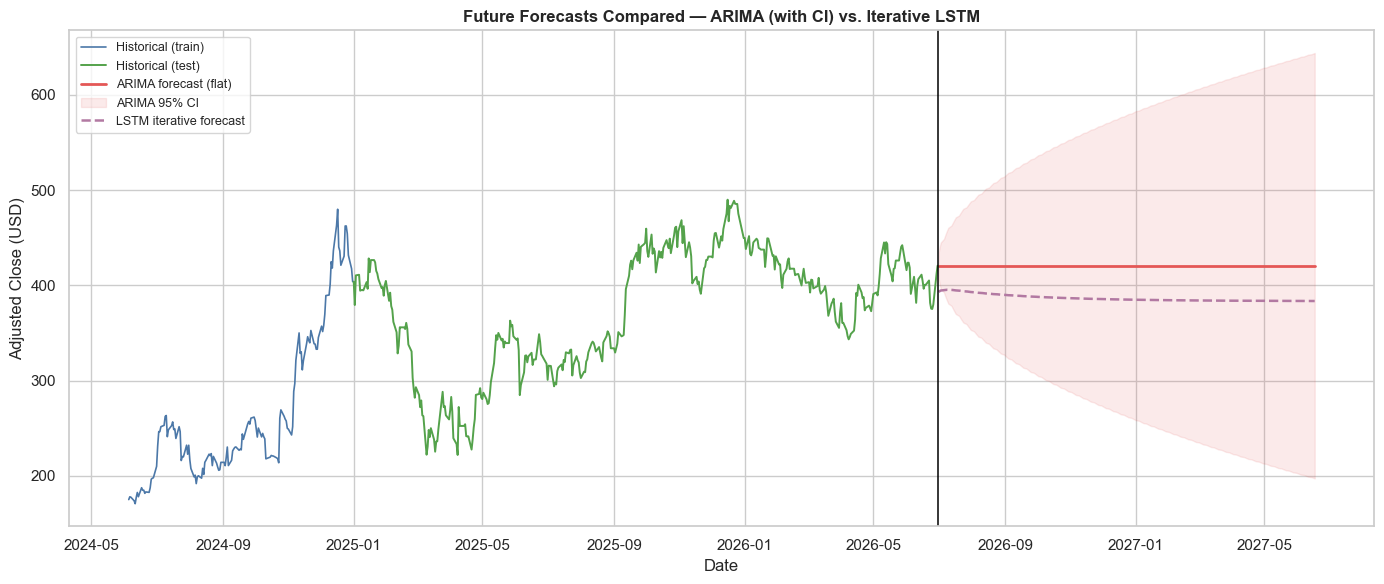

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.iloc[-150:].index, train.iloc[-150:], color=C_HIST, lw=1.2, label="Historical (train)")
ax.plot(test.index, test, color=C_TEST, lw=1.4, label="Historical (test)")
ax.plot(future_idx, future, color=C_FCAST, lw=2, label="ARIMA forecast (flat)")
ax.fill_between(future_idx, ci95["lo95"], ci95["hi95"], color=C_CI, alpha=0.12, label="ARIMA 95% CI")
ax.plot(future_idx, lstm_future, color=C_LSTM, lw=1.8, ls="--", label="LSTM iterative forecast")
ax.axvline(last_date, color="black", lw=1.1)
ax.set_title("Future Forecasts Compared — ARIMA (with CI) vs. Iterative LSTM")
ax.set_ylabel("Adjusted Close (USD)"); ax.set_xlabel("Date"); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

## 7 · Trend Analysis Summary

**Long-term trend.** The best model's point forecast is **flat** at roughly the last observed price
(the endpoint values are printed in §3). This is not a modelling failure — it is the direct consequence
of TSLA behaving like a **random walk** (confirmed by the ADF tests in Task 1 and the ARIMA(0,1,0)
selection in Task 2): the statistically optimal expectation for tomorrow, and every day after, is "the
same as today." The with-drift scenario (§3) extrapolates TSLA's historical climb to a higher endpoint,
**but the drift coefficient is not statistically significant**, so we treat the flat path as the honest
central estimate and the drift path only as an optimistic what-if. The iterative LSTM produces a gently
drifting line that quickly flattens — a well-known symptom of error compounding in recursive multi-step
forecasting, and it comes with **no calibrated uncertainty band**.

**Patterns & anomalies.** The defining feature of the forecast is not the point estimate but the
**rapidly fanning confidence interval**. There is no seasonality or cyclical pattern to exploit (Task 2
found none). The only "pattern" is monotonically growing uncertainty: the 95% band widens roughly in
proportion to **√horizon**, so it roughly doubles every time the horizon quadruples.


## 8 · Market Opportunities & Risks

**Opportunities**
- **Wide upside band.** The 95% CI's *upper* bound rises to well above the current price over 12 months
  (see §5 table) — consistent with TSLA's history of large rallies. The non-significant-but-positive
  historical drift means the odds are tilted slightly upward, offering meaningful upside for
  risk-tolerant capital.
- **Volatility itself is tradable.** Persistently high, clustering volatility (Task 1) creates
  opportunity for volatility-aware sizing and for options/rebalancing strategies rather than static
  buy-and-hold.
- **Diversification benefit.** Because TSLA's expected path is uncertain but its return potential is
  high, holding it in *combination* with SPY/BND (Task 4) can capture upside while dampening portfolio
  variance.

**Risks**
- **Large downside band.** The same CI extends far *below* today's price — a 95%-level 12-month downside
  that represents a substantial drawdown. TSLA's worst historical day was −21% (Task 1); tail risk is
  real.
- **No reliable directional signal.** The flat point forecast means the model provides **no edge on
  direction** — betting on price level alone is speculation, not strategy.
- **Model/assumption risk.** The forecast assumes the return-generating process is stable; regime shifts
  (rates, demand, competition, key-person risk) are not captured and would break the random-walk
  assumption.

**Uncertainty captured by the CI.** The interval is honest and calibrated but **very wide** — at 12
months the 95% band spans a large fraction of the current price (§5). It communicates clearly that
precise long-horizon price prediction is not achievable for this asset.


## 9 · Critical Assessment — Forecast Reliability by Horizon

| Horizon | Reliability | Rationale |
|---------|-------------|-----------|
| **1 day (one-step)** | **High** | Task 2 MAPE ≈ 2.5%; tomorrow ≈ today is a strong predictor. |
| **~1 month** | Moderate | CI still relatively narrow; point estimate usable for planning ranges. |
| **~3–6 months** | Low | CI width becomes a large share of price; direction is essentially unknown. |
| **~9–12 months** | Very low | CI spans a huge range; the forecast is a *distribution of scenarios*, not a point call. |

**Why reliability decays.** For a random walk the forecast variance accumulates linearly with time, so
the standard error — and thus CI width — grows with **√horizon** (verified in §5, where the empirical
width tracks the √h reference line almost exactly). Each additional day adds irreducible uncertainty
that cannot be forecast away.

**Practical implications.**
1. **Use short horizons for point decisions, long horizons only for scenario/range planning.** Trust the
   one-step accuracy; treat the 12-month number as a wide band, never a target.
2. **Report the interval, not just the line.** The value of this forecast is the *uncertainty it
   quantifies*, which is exactly why ARIMA (native CIs) is preferable to the LSTM (no calibrated bands)
   for decision-making here.
3. **Manage, don't predict.** The correct response to this fundamentally unpredictable long-run path is
   **diversification and mean–variance optimization** (Task 4) — sizing TSLA within a portfolio to
   harvest its upside while controlling downside — rather than making a levered directional bet on the
   point forecast.

> **Bottom line:** the model is reliable for *next-day* forecasting and for *quantifying uncertainty*,
> but it correctly tells us that Tesla's 12-month price is not precisely predictable. That humility is
> the actionable insight — it points the strategy toward portfolio construction, not price bets.
